<h1 style="text-align: center;">Task-1P</h1>
<h3 style="text-align: right;">Name: Yatharth Deoly</h3>
<h3 style="text-align: right;">StudentId: 224207854</h3>
<h3 style="text-align: right;">EmailId: yatharthdeoly@gmail.com</h3>


## Introduction

In 2012, Council and ARUP partnered with the University of Melbourne on a three year Australian Research Council Linkage Grant for Creating a Smart City through Internet of Things. The aim of the research was to develop new systems and algorithms that can help City administrators remotely monitor, understand and interpret real time information on urban environments.

Using this dataset we will be learning the dataset and will be applying different pre-processing and visualization.


Defining imports at the top that will be used by the report.
In this case, having all the imports at the top is more intuitive than having some of them at the top and some of them scattered over the file.


In [1]:
import pandas as pd

import warnings

# Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.
import matplotlib.pyplot as plt

# Seaborn is a Python visualization library based on matplotlib. It provides a high-level interface for drawing attractive statistical graphics.
import seaborn as sns

# Ignore all warnings generated by the Python program
warnings.filterwarnings("ignore")

# This command tells the IPython environment to draw the plots immediately after the current cell
%matplotlib inline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

from sklearn.preprocessing import MinMaxScaler

# Apply min-max scaling
scaler = MinMaxScaler()

random_state = 42

Extracting data into pandas Dataframe from a file.


In [2]:
sensor_df = pd.read_csv(
    "sensor-readings-with-temperature-light-humidity-every-5-minutes-at-8-locations-t.csv"
)

# Printing random 5 data from our dataframe
sensor_df.sample(n=5, random_state=random_state)

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,...,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,Position,geolocation
38354,2015-04-22T11:55:00+05:30,0013a20040b31583,1,509,16.8,16.8,16.8,79.6,79.6,79.6,...,66.1,66.1,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150422062500,NaN,"-37.8199043, 144.9404851"
32603,2015-04-10T04:25:00+05:30,0013a20040b31571,1,510,20.0,20.0,20.0,96.3,96.3,96.3,...,43.1,43.1,ENV,-37.819712,144.941325,2.74,Docklands Library,510-20150409225500,NaN,"-37.8197121, 144.9413253"
15074,2015-04-15T04:30:00+05:30,0013a20040b31571,1,510,21.3,21.3,21.3,96.6,96.6,96.6,...,48.8,48.8,ENV,-37.819712,144.941325,2.74,Docklands Library,510-20150414230000,NaN,"-37.8197121, 144.9413253"
54737,2015-01-21T12:05:00+05:30,0013a20040b31583,1,509,33.5,33.5,33.5,97.6,97.6,97.6,...,25.1,25.1,ENV,-37.819904,144.940485,NaN,Docklands Library,509-20150121063500,NaN,"-37.8199043, 144.9404851"
12065,2015-03-24T09:00:00+05:30,0013a20040b31583,1,509,14.8,14.8,14.8,94.7,94.7,94.7,...,54.8,54.8,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150324033000,NaN,"-37.8199043, 144.9404851"


In [3]:
print(
    f"Sensor dataset have {sensor_df.shape[0]} entries for {sensor_df.shape[1]} features."
)

Sensor dataset have 56570 entries for 21 features.


In [4]:
# Backing-up the dataset for future usage as we will be performing EDA/pre-processing on it.
sensor_df_backup = sensor_df.copy(deep=True)

In [5]:
# Check for missing values
missing_values = sensor_df.isnull().sum()

# Print feature names with the number of missing entries
print("Feature names with the number of missing entries:")
print(missing_values)

Feature names with the number of missing entries:
timestamp           0
mac                 0
boardtype           0
boardid             0
temp_max            0
temp_min            0
temp_avg            0
light_max           0
light_min           0
light_avg           0
humidity_min        0
humidity_max        0
humidity_avg        0
model               0
latitude            0
longitude           0
elevation       21595
location            0
rowid               0
Position        56570
geolocation         0
dtype: int64


From the above check, we got to know:

- `Position` feature: In the given dataset there is no value for this feature, so it will be good that we drop this column for our further analysis.
- `elevation` feature: In the given dataset 38% of values are missing, so for this feature we can impute the value by some mathematical functions like mean, mode, median or we can use directly sklearn imputers like SimpleImputer, IterativeImputer, KNNImputer and more.


Dropping `Position` feature from the dataset


In [6]:
sensor_df.drop(columns="Position", inplace=True)
sensor_df.sample(n=5, random_state=random_state)

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,geolocation
38354,2015-04-22T11:55:00+05:30,0013a20040b31583,1,509,16.8,16.8,16.8,79.6,79.6,79.6,66.1,66.1,66.1,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150422062500,"-37.8199043, 144.9404851"
32603,2015-04-10T04:25:00+05:30,0013a20040b31571,1,510,20.0,20.0,20.0,96.3,96.3,96.3,43.1,43.1,43.1,ENV,-37.819712,144.941325,2.74,Docklands Library,510-20150409225500,"-37.8197121, 144.9413253"
15074,2015-04-15T04:30:00+05:30,0013a20040b31571,1,510,21.3,21.3,21.3,96.6,96.6,96.6,48.8,48.8,48.8,ENV,-37.819712,144.941325,2.74,Docklands Library,510-20150414230000,"-37.8197121, 144.9413253"
54737,2015-01-21T12:05:00+05:30,0013a20040b31583,1,509,33.5,33.5,33.5,97.6,97.6,97.6,25.1,25.1,25.1,ENV,-37.819904,144.940485,NaN,Docklands Library,509-20150121063500,"-37.8199043, 144.9404851"
12065,2015-03-24T09:00:00+05:30,0013a20040b31583,1,509,14.8,14.8,14.8,94.7,94.7,94.7,54.8,54.8,54.8,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150324033000,"-37.8199043, 144.9404851"


Imputing value for `elevation` feature, using mean or median method.
To decide which strategy to be used, will be checking both scenario and making the decision.


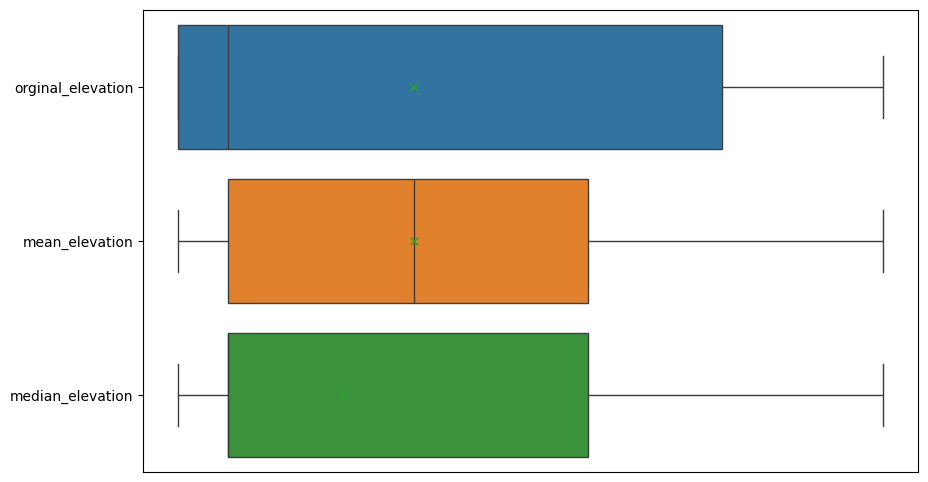

In [7]:
# Making 2 different dataframe for elevation
s_mean_elevation = sensor_df["elevation"].copy(deep=True)
s_median_elevation = sensor_df["elevation"].copy(deep=True)

# Creating imputer of mean strategy
imputer_mean = SimpleImputer(strategy="mean")
s_mean_elevation = imputer_mean.fit_transform(s_mean_elevation.values.reshape(-1, 1))

# Creating imputer of median strategy
imputer_median = SimpleImputer(strategy="median")
s_median_elevation = imputer_median.fit_transform(
    s_median_elevation.values.reshape(-1, 1)
)

# Create the boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data={
        "orginal_elevation": sensor_df["elevation"],
        "mean_elevation": s_mean_elevation.flatten(),
        "median_elevation": s_median_elevation.flatten(),
    },
    orient="h",
    showmeans=True,
    meanprops={"marker": "x", "color": "green"},
)

# Turn off the y-axis labels
plt.xticks([])

# Show the plot
plt.show()

From the above visualization, its derived that we can use any of the strategy, so here we will be going with mean strategy as in that 25<sup>th</sup>, 50<sup>th</sup> and 75<sup>th</sup> percentiles, are being present and bifurcated also.
Also mean is suitable as the data is symmetrically distributed without significant outliers. It provides a good central tendency for normally distributed data.
So we will use mean strategy where median and mean is same.


In [8]:
replacement_value = sensor_df["elevation"].mean()

sensor_df["elevation"] = imputer_mean.fit_transform(
    sensor_df["elevation"].values.reshape(-1, 1)
)

print(f"Replacement value used for elevation feature: {replacement_value}")
sensor_df.sample(n=5, random_state=random_state)

Replacement value used for elevation feature: 12.973809578270192


,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,geolocation
38354,2015-04-22T11:55:00+05:30,0013a20040b31583,1,509,16.8,16.8,16.8,79.6,79.6,79.6,66.1,66.1,66.1,ENV,-37.819904,144.940485,0.03000,Docklands Library,509-20150422062500,"-37.8199043, 144.9404851"
32603,2015-04-10T04:25:00+05:30,0013a20040b31571,1,510,20.0,20.0,20.0,96.3,96.3,96.3,43.1,43.1,43.1,ENV,-37.819712,144.941325,2.74000,Docklands Library,510-20150409225500,"-37.8197121, 144.9413253"
15074,2015-04-15T04:30:00+05:30,0013a20040b31571,1,510,21.3,21.3,21.3,96.6,96.6,96.6,48.8,48.8,48.8,ENV,-37.819712,144.941325,2.74000,Docklands Library,510-20150414230000,"-37.8197121, 144.9413253"
54737,2015-01-21T12:05:00+05:30,0013a20040b31583,1,509,33.5,33.5,33.5,97.6,97.6,97.6,25.1,25.1,25.1,ENV,-37.819904,144.940485,12.97381,Docklands Library,509-20150121063500,"-37.8199043, 144.9404851"
12065,2015-03-24T09:00:00+05:30,0013a20040b31583,1,509,14.8,14.8,14.8,94.7,94.7,94.7,54.8,54.8,54.8,ENV,-37.819904,144.940485,0.03000,Docklands Library,509-20150324033000,"-37.8199043, 144.9404851"


In [9]:
# Check for missing values
sensor_df.isnull().sum()

timestamp       0
mac             0
boardtype       0
boardid         0
temp_max        0
temp_min        0
temp_avg        0
light_max       0
light_min       0
light_avg       0
humidity_min    0
humidity_max    0
humidity_avg    0
model           0
latitude        0
longitude       0
elevation       0
location        0
rowid           0
geolocation     0
dtype: int64

As from above sample, there is missing data present in our dataset. Now we can use this dataset for our further usage.


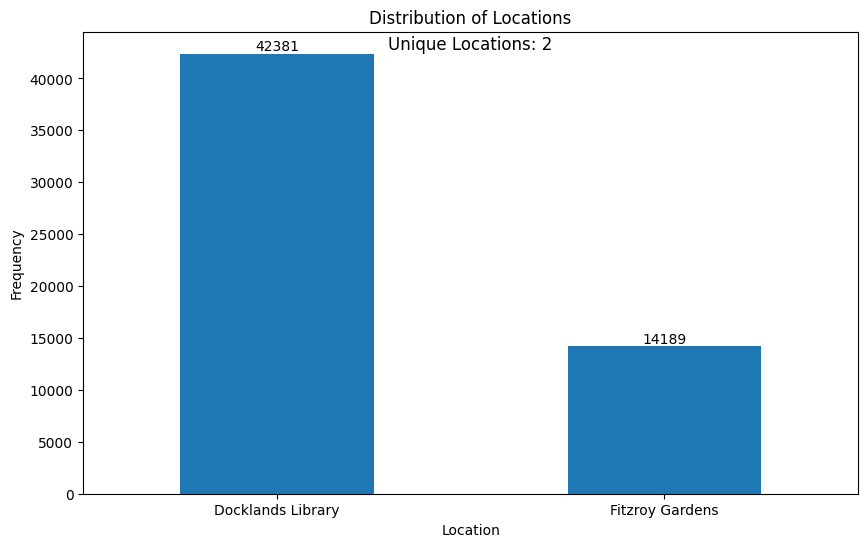

In [10]:
# Plot histogram for the 'location' variable
plt.figure(figsize=(10, 6))

# Plot the bar chart and store the Axes object
ax = sensor_df["location"].value_counts().plot(kind="bar")

# Set titles, labels and rotation
plt.title("Distribution of Locations")
plt.xlabel("Location")
plt.ylabel("Frequency")
plt.xticks(rotation=0)

# Display the number of unique locations at the top
plt.text(
    0.5,
    max(sensor_df["location"].value_counts()) + 1,
    f"Unique Locations: {sensor_df["location"].nunique()}",
    ha="center",
    va="bottom",
    fontsize=12,
)

# Display the frequencies of each location as text annotations
for i, (loc, freq) in enumerate(sensor_df["location"].value_counts().items()):
    plt.text(i, freq, str(freq), ha="center", va="bottom")

# Show the plot
plt.show()

This visualization helps in understanding the distribution of sensor readings across different locations and highlights the disparity in data collection volumes between the two locations.

- There are total 2 unique locations present in our dataset, ie. `Docklands Library` and `Fitzory Gardens`.
- `Docklands Library` has the highest number of sensor readings, with a total of 42,381 sensor readings.
- `Fitzory Gardens` has fewer sensor readings compared to `Docklands Library`, with a total of 14,189 sensor readings.
- The bar representing `Docklands Library` is significantly taller than the bar for `Fitzroy Gardens`, indicating a much higher number of sensor readings.


Encode the categorical variable `location` using encoding approach


In this case `location` feature have 2 unique values i.e. `Docklands Library` and `Fitzory Gardens`, so for this scenario Label Encoding will be best approach. It will represent the categories as `0` and `1`.
Using this approach there won't be any additional columns.


In [11]:
# Fit and transform the 'location' column
sensor_df["location"] = label_encoder.fit_transform(sensor_df["location"])

In [12]:
# Retrieve the mapping of labels to integers
label_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)

# Display the mapping
print("Label Encoding Mapping:")
for label, encoded_value in label_mapping.items():
    print(f"{label}: {encoded_value}")

Label Encoding Mapping:
Docklands Library: 0
Fitzroy Gardens: 1


To encode categorical variable for `location` feature, we have used LabelEncoder and which have transformed `location` feature as `0` and `1`.

- `Docklands Library` has been encoded as `0`.
- `Fitzroy Gardens` has been encoded as `1`.


In [13]:
# Dataset after encoding for location as `Docklands Library`
sensor_df[sensor_df["location"] == 0].sample(n=2, random_state=random_state)

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,geolocation
54622,2015-01-21T05:10:00+05:30,0013a20040b5b337,1,511,26.8,26.8,26.8,96.1,96.1,96.1,36.2,36.2,36.2,ENV,-37.819500,144.941889,12.97381,0,511-20150120234000,"-37.8195002, 144.9418888"
941,2015-02-04T22:45:00+05:30,0013a20040b31571,1,510,14.2,14.2,14.2,1.2,1.2,1.2,53.7,53.7,53.7,ENV,-37.819712,144.941325,12.97381,0,510-20150204171500,"-37.8197121, 144.9413253"


In [14]:
# Dataset after encoding for location as `Fitzroy Gardens`
sensor_df[sensor_df["location"] == 1].sample(n=2, random_state=random_state)

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,geolocation
23832,2015-02-26T04:35:00+05:30,0013a20040b4b755,1,508,19.0,19.0,19.0,91.5,91.5,91.5,52.6,52.6,52.6,ENV,-37.813408,144.979492,30.10,1,508-20150225230500,"-37.8134078, 144.9794923"
7194,2014-12-17T22:10:00+05:30,0013a20040b516f6,1,507,11.6,11.6,11.6,1.1,1.1,1.1,49.1,49.1,49.1,ENV,-37.814922,144.982258,38.79,1,507-20141217164000,"-37.8149218, 144.9822582"


Applying min-max scaling on specific features.

Min-max scaling, also known as min-max normalization, is a common data preprocessing technique in machine learning that scales numerical features to a fixed range, usually between 0 and 1.

$$ X*{norm}=(X-X*{min})/(X*{max}-X*{min}) $$
Where X<sub>min</sub> and X<sub>max</sub> are the minimum and maximum values in the feature, respectively.


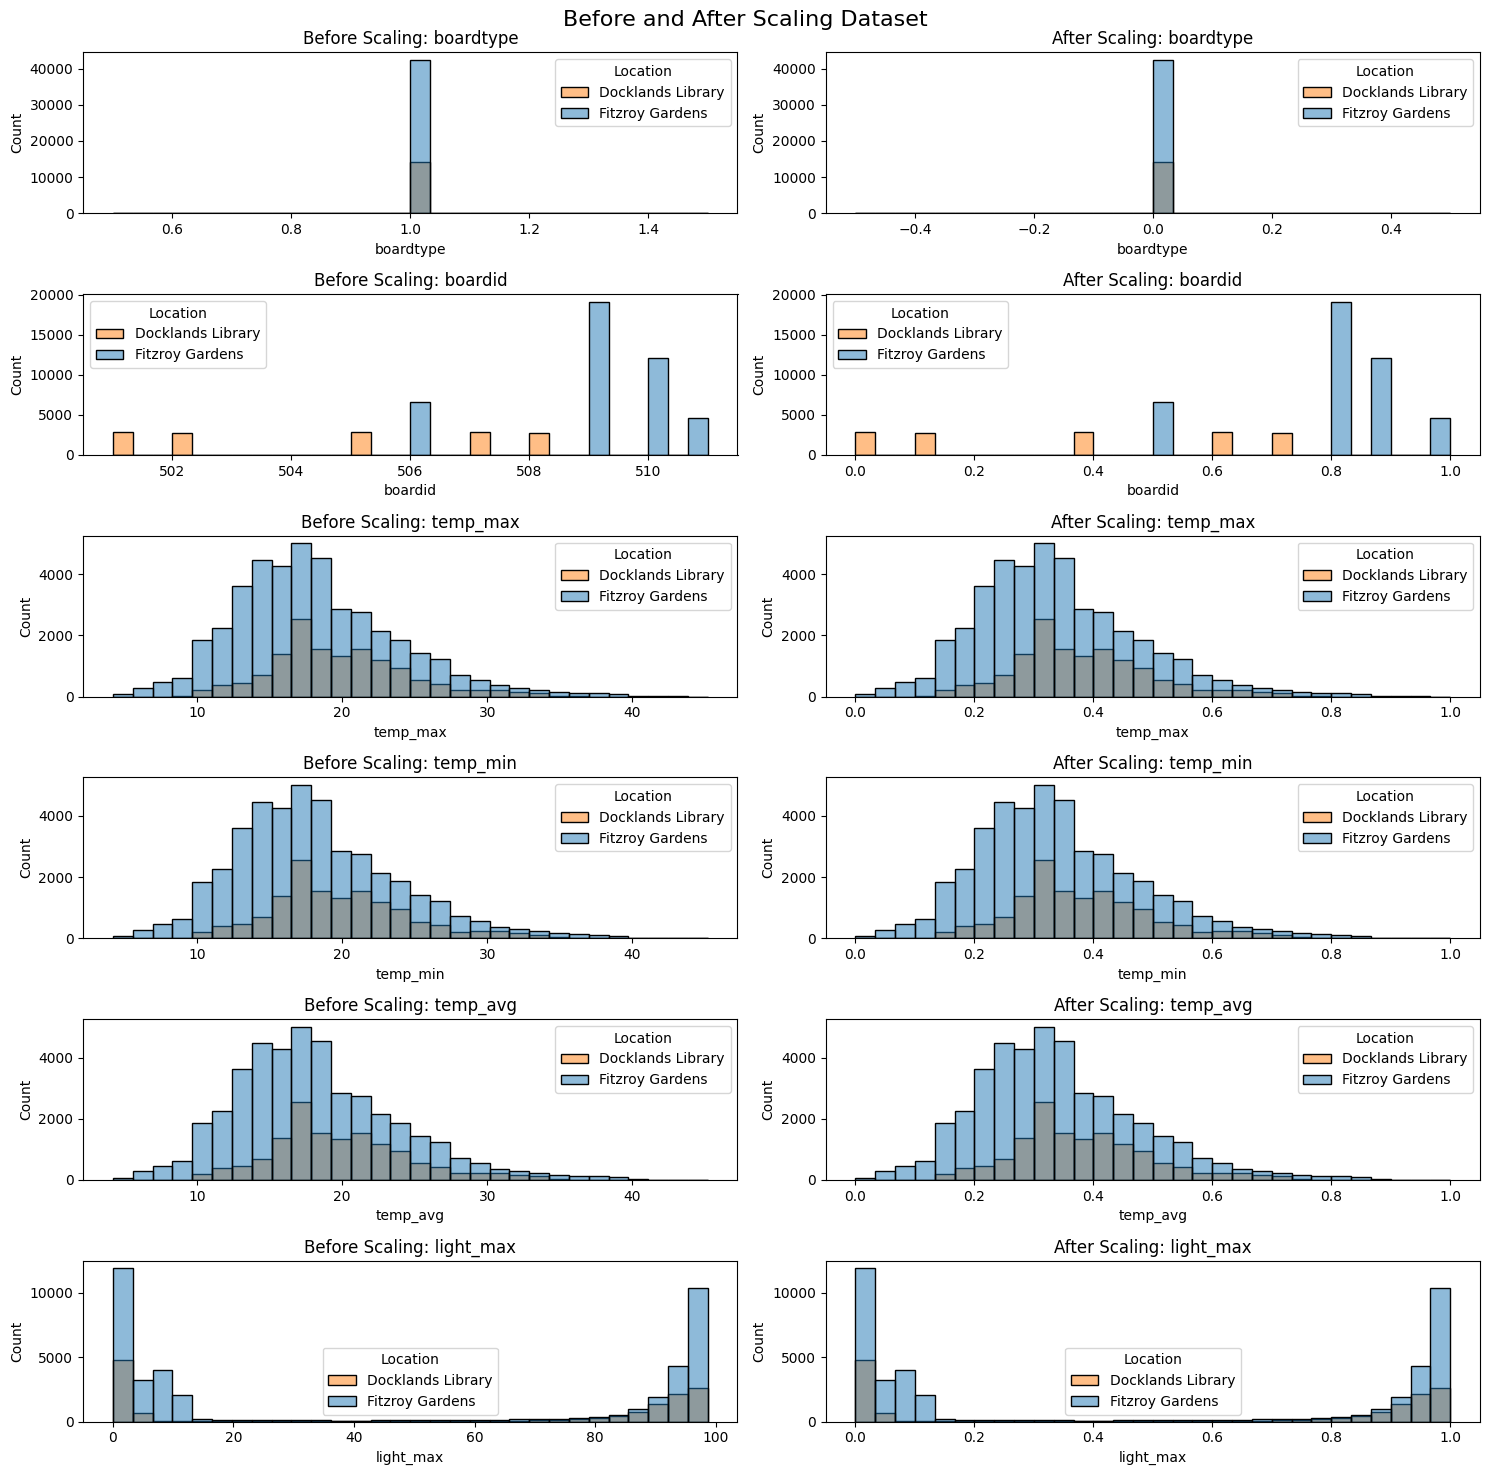

In [15]:
# Features to scale
features_to_scale = [
    "boardtype",
    "boardid",
    "temp_max",
    "temp_min",
    "temp_avg",
    "light_max",
    "light_min",
    "light_avg",
    "humidity_min",
    "humidity_max",
    "humidity_avg",
]

sensor_df_scaling = sensor_df.copy(deep=True)
sensor_df_scaling[features_to_scale] = scaler.fit_transform(
    sensor_df_scaling[features_to_scale]
)

# Plot distributions before scaling
fig, axs = plt.subplots(6, 2, figsize=(15, 15))
fig.suptitle("Before and After Scaling Dataset", fontsize=16)

for i, feature in enumerate(features_to_scale[:6]):
    sns.histplot(
        data=sensor_df,
        x=feature,
        hue="location",
        bins=30,
        alpha=0.5,
        ax=axs[i, 0],
    )
    axs[i, 0].set_title(f"Before Scaling: {feature}")
    axs[i, 0].legend(label_encoder.classes_, title="Location")

    sns.histplot(
        data=sensor_df_scaling,
        x=feature,
        hue="location",
        bins=30,
        alpha=0.5,
        ax=axs[i, 1],
    )
    axs[i, 1].set_title(f"After Scaling: {feature}")
    axs[i, 1].legend(label_encoder.classes_, title="Location")

plt.tight_layout()
plt.show()

Differences that has been encountered from above visulatisaion between before and after min-max scaling:

- Range of values difference, as original dataset will have different and random range values but after scaling, dataset will be normalized with range between 0 and 1.
- Scale range, as all features before have different ranges for all features but after min-max scaling all features will have similar scale, that will help model training.
- As after scaling is just an mirror image of larger range dataset, so visulatisaion won't so that much difference.

But scaling/normalizing is a better and good option because it helps different algorithms to work faster like KNN, SVM and more.


# Summary

In this report we have learnt about the different pre-processing that can used over data to make dataset ready for use purpose.
Here we have learnt about different libraries from python, sklearn from loading the file to the pre-processing of the data.

# References

- https://discover.data.vic.gov.au/dataset/sensor-readings-with-temperature-light-humidity-every-5-minutes-at-8-locations-trial-2014-2015
- Great Learning dashboard for PGP-AIML
- Different blogs from https://medium.com/
- https://scikit-learn.org/stable/api/sklearn.preprocessing.html
